# Problemas de Estadística Descriptiva

## Ejercicio 1 – ¿Qué tan largos son los títulos de las películas?

En este ejercicio vas a aplicar técnicas de estadística descriptiva sobre un conjunto de datos real: una base con 1000 películas populares del sitio IMDb.

A partir del título de cada película, vas a:
- Calcular la longitud del título (en caracteres).
- Obtener métricas estadísticas clave: media, mediana, moda, rango, varianza, desviación estándar, asimetría y curtosis.
- Identificar los títulos más largos y más cortos.
- Visualizar la distribución de estas longitudes con un histograma y una curva de densidad.


In [40]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, mode

# Cargar dataset de IMDb
url = "../assets/imdb_1000.csv"
df = pd.read_csv(url)
df

,star_rating,title,content_rating,genre,duration,actors_list
0,9.3,The Shawshank Redemption,R,Crime,142,"[u'Tim Robbins', u'Morgan Freeman', u'Bob Gunt..."
1,9.2,The Godfather,R,Crime,175,"[u'Marlon Brando', u'Al Pacino', u'James Caan']"
2,9.1,The Godfather: Part II,R,Crime,200,"[u'Al Pacino', u'Robert De Niro', u'Robert Duv..."
3,9.0,The Dark Knight,PG-13,Action,152,"[u'Christian Bale', u'Heath Ledger', u'Aaron E..."
4,8.9,Pulp Fiction,R,Crime,154,"[u'John Travolta', u'Uma Thurman', u'Samuel L...."
...,...,...,...,...,...,...
974,7.4,Tootsie,PG,Comedy,116,"[u'Dustin Hoffman', u'Jessica Lange', u'Teri G..."
975,7.4,Back to the Future Part III,PG,Adventure,118,"[u'Michael J. Fox', u'Christopher Lloyd', u'Ma..."
976,7.4,Master and Commander: The Far Side of the World,PG-13,Action,138,"[u'Russell Crowe', u'Paul Bettany', u'Billy Bo..."
977,7.4,Poltergeist,PG,Horror,114,"[u'JoBeth Williams', u""Heather O'Rourke"", u'Cr..."


In [41]:
# Crea una nueva columna llamada 'title_length' con la longitud (número de caracteres) de cada título
df['title_length'] = df['title'].str.len()
df["title_length"].head()

0    24
1    13
2    22
3    15
4    12
Name: title_length, dtype: int64

In [42]:
# Calcula media, mediana y moda de la columna 'title_length'
media = df['title_length'].mean()
mediana = df['title_length'].median()
moda = df['title_length'].mode()[0]

print(f"Media: {media:.2f}")
print(f"Mediana: {mediana}")
print(f"Moda: {moda}")

Media: 15.48
Mediana: 14.0
Moda: 12


In [43]:
# Calcula el rango, la varianza y la desviación estándar de 'title_length'
rango = df['title_length'].max() - df['title_length'].min()
varianza = df['title_length'].var()
desviacion_std = df['title_length'].std()

print(f"Rango: {rango}")
print(f"Varianza: {varianza:.2f}")
print(f"Desviación Estándar: {desviacion_std:.2f}")


Rango: 67
Varianza: 72.11
Desviación Estándar: 8.49


In [44]:
# Calcula asimetría y curtosis de la columna 'title_length'
asimetria = df['title_length'].skew()
curtosis = df['title_length'].kurtosis()

print(f"Asimetría: {asimetria:.2f}")
print(f"Curtosis: {curtosis:.2f}")

Asimetría: 1.53
Curtosis: 3.81


In [45]:
# Imprime el título más corto y el título más largo según su longitud
print("Títulos más largos")
print(df[['title', 'title_length']].nlargest(1, 'title_length'))
print("----------------------------------------------------------------------------")
print("Títulos más cortos")
print(df[['title', 'title_length']].nsmallest(1, 'title_length'))

Títulos más largos
                                                title  title_length
48  Dr. Strangelove or: How I Learned to Stop Worr...            68
----------------------------------------------------------------------------
Títulos más cortos
   title  title_length
63     M             1


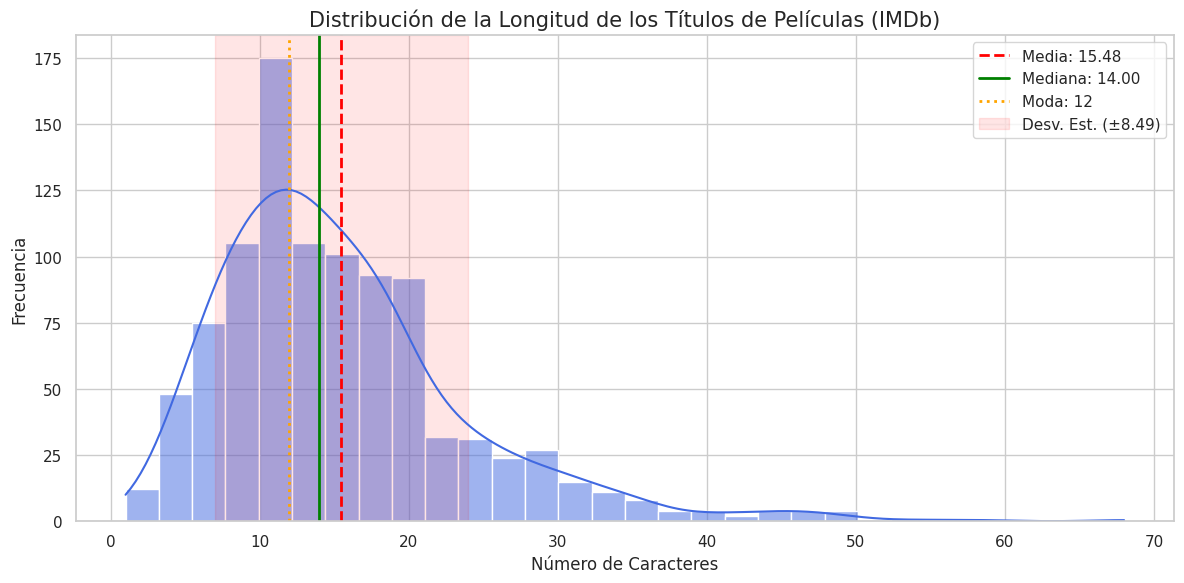

In [46]:
# grafica tus resultados
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(df['title_length'], kde=True, color='royalblue', bins=30)
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.axvline(moda, color='orange', linestyle=':', linewidth=2, label=f'Moda: {moda}')
plt.axvspan(media - desviacion_std, media + desviacion_std, color='red', alpha=0.1, 
            label=f'Desv. Est. (±{desviacion_std:.2f})')

plt.title('Distribución de la Longitud de los Títulos de Películas (IMDb)', fontsize=15)
plt.xlabel('Número de Caracteres', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()




---

## Ejercicio 2 – Cálculo manual de desviación estándar

En este ejercicio vas a calcular manualmente la desviación estándar, seleccionando cinco títulos reales del dataset de películas que cargaste antes.


In [47]:
# Crea una lista con 5 valores reales de df['title_length'], por ejemplo: [10, 13, 14, 18, 22]
valores = [10, 13, 14, 18, 22]

print(f"Datos seleccionados: {valores}")

Datos seleccionados: [10, 13, 14, 18, 22]


In [48]:
# Calcula la media de los 5 valores
n = len(valores)
media = sum(valores) / n
print(f"Media: {media}")

Media: 15.4


In [56]:
# Calcula las diferencias al cuadrado con respecto a la media
dif_cuadrado = [(x - media)**2 for x in valores]


print("\nDiferencias al cuadrado (val.i - media)^2:")
for i, dif in enumerate(dif_cuadrado):
    print(f"Dato {valores[i]}: ({valores[i]} - {media})² = {dif:.2f}")

suma_diferencias = sum(dif_cuadrado)
print(f"Suma diferencias al cuadrado: {suma_diferencias:.2f}")


Diferencias al cuadrado (val.i - media)^2:
Dato 10: (10 - 15.4)² = 29.16
Dato 13: (13 - 15.4)² = 5.76
Dato 14: (14 - 15.4)² = 1.96
Dato 18: (18 - 15.4)² = 6.76
Dato 22: (22 - 15.4)² = 43.56
Suma diferencias al cuadrado: 87.20


In [55]:
# Calcula la varianza (promedio de las diferencias al cuadrado) y su raíz cuadrada para obtener la desviación
varianza = suma_diferencias / len(valores)
desviacion_manual = varianza ** 0.5

print(f"Varianza: {varianza:.2f}")
print(f"Desviación estándar: {desviacion_manual:.2f}")


Varianza: 17.44
Desviación estándar: 4.18
